In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [2]:
from google.colab import files
files.upload()

Saving car_price_prediction.csv to car_price_prediction.csv


{'car_price_prediction.csv': b'ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags\n45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12\n44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8\n45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2\n45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0\n45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4\n45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4\n45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White

In [3]:
data=pd.read_csv('car_price_prediction.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [5]:
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [6]:
data .shape


(19237, 18)

In [7]:
data.isna().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [8]:
data.duplicated().sum()
data.drop_duplicates(inplace=True)

In [9]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.892400e+04,1.892400e+04,18924.000000,18924.000000,18924.000000
mean,4.557538e+07,1.858744e+04,2010.914236,4.580216,6.568379
std,9.375468e+05,1.921356e+05,5.665749,1.200223,4.322323
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569501e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580174e+07,2.206300e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [10]:
data.select_dtypes(include='object').describe()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5709,3729,1069,8600,13731,9944,3856,714,13282,12695,18032,17471,4944


In [11]:
def top_buttom_combined(df,col,n=5):
  top_countes=df[col].value_counts().head(n)
  buttom_counts=df[col].value_counts().tail(n)

  combined=pd.concat([top_countes,buttom_counts])
  combined.coloums=['Most freuent','least frequent']
  return combined

for col in data.select_dtypes(include='object')  :
  print(f'{col} value count:')
  print(top_buttom_combined(data,col))
  print('30 unique value:',data[col].unique()[:30])
  print('-------------------------------')



Levy value count:
Levy
-       5709
765      482
891      453
639      403
640      398
2308       1
4860       1
1641       1
1045       1
1901       1
Name: count, dtype: int64
30 unique value: ['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053' '1055'
 '1079' '810' '2386' '1850' '531' '586' '1249' '2455' '583' '1537' '1288'
 '915' '1750' '707' '1077' '1486' '1091' '650' '382']
-------------------------------
Manufacturer value count:
Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, dtype: int64
30 unique value: ['LEXUS' 'CHEVROLET' 'HONDA' 'FORD' 'HYUNDAI' 'TOYOTA' 'MERCEDES-BENZ'
 'OPEL' 'PORSCHE' 'BMW' 'JEEP' 'VOLKSWAGEN' 'AUDI' 'RENAULT' 'NISSAN'
 'SUBARU' 'DAEWOO' 'KIA' 'MITSUBISHI' 'SSANGYONG' 'MAZDA' 'GMC' 'FIAT'
 'INFINITI' 'ALFA ROMEO' 'SUZUKI' 'ACURA' 'LINCOLN' 'VAZ' 'GA

In [ ]:
data['Levy'].replace({'-': 0}, inplace=True)
data['Levy']=pd.to_numeric(data['Levy']).


/tmp/ipykernel_5198/838492485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Levy'].replace({'-': 0}, inplace=True)


In [13]:
data['Engine volume']=data['Engine volume'].str.replace('Turbo','')
data['Engine volume']=pd.to_numeric(data['Engine volume'])

In [14]:
data.drop(['Doors'],axis=1,inplace=True)

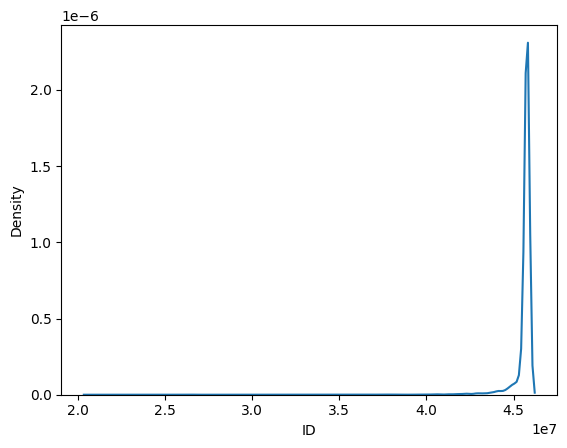

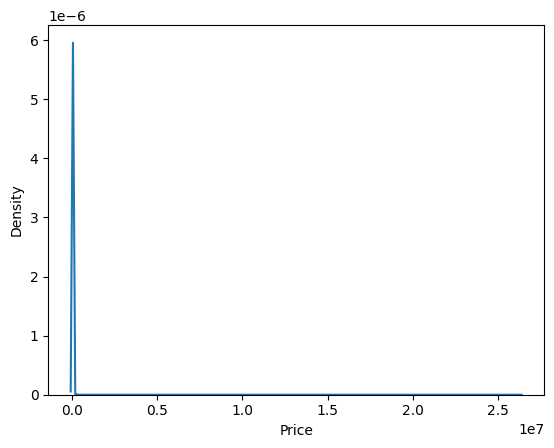

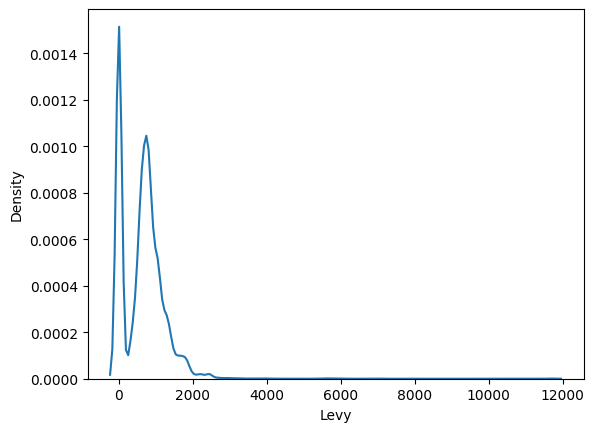

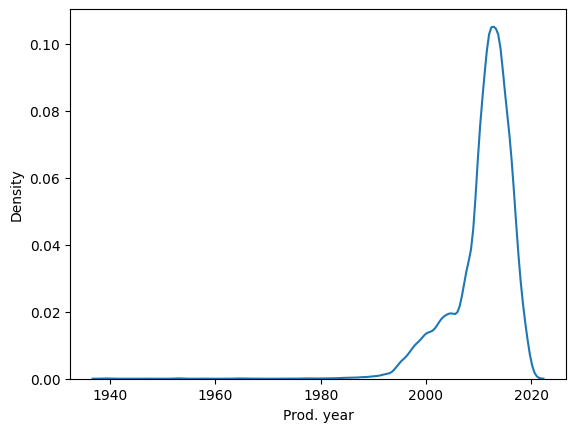

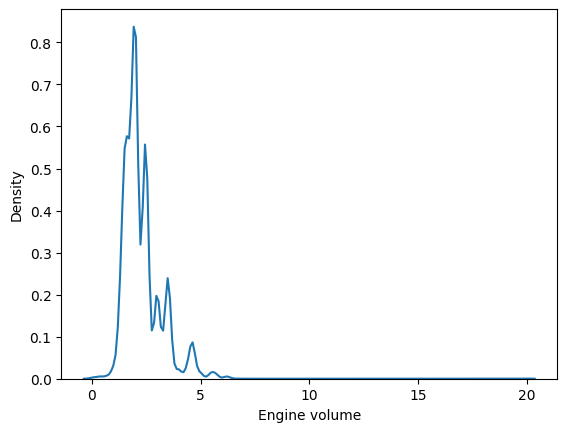

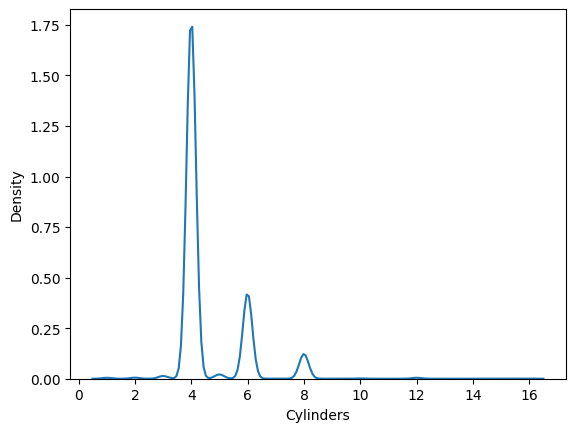

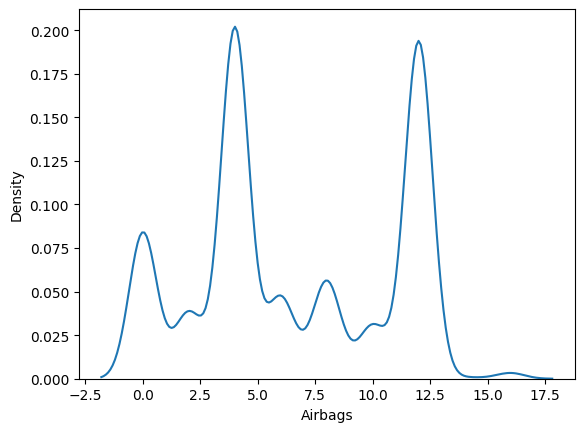

In [ ]:
for col in data.select_dtypes('number').columns:
  sns.kdeplot(data[col])
  plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Mileage', ylabel='Density'>

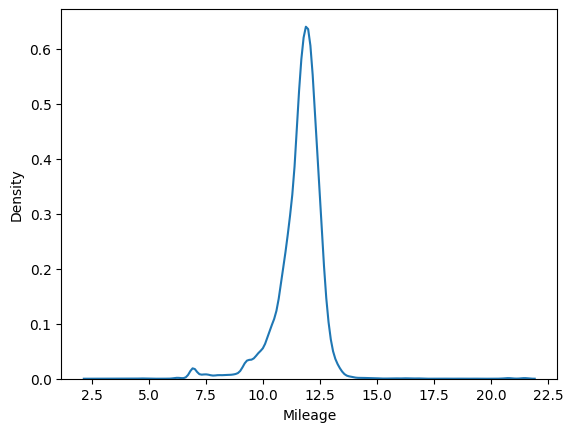

In [16]:
data['Mileage'] = data['Mileage'].str.replace(' km', '').astype(float)
sns.kdeplot(np.log(data['Mileage']))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Mileage', ylabel='Density'>

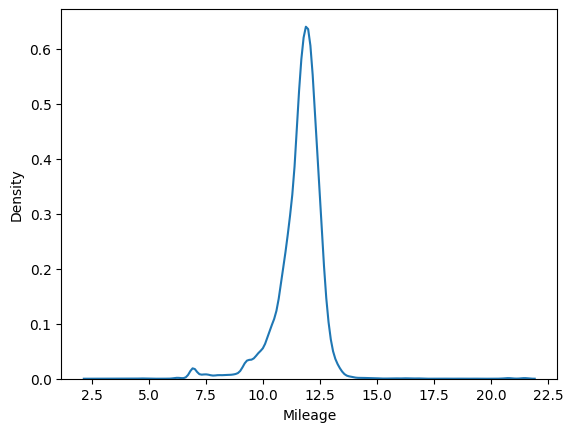

In [26]:
if data['Mileage'].dtype == 'object':
    data['Mileage'] = data['Mileage'].str.replace(' km', '', regex=False).astype(float)
sns.kdeplot(np.log(data['Mileage']))

<Axes: >

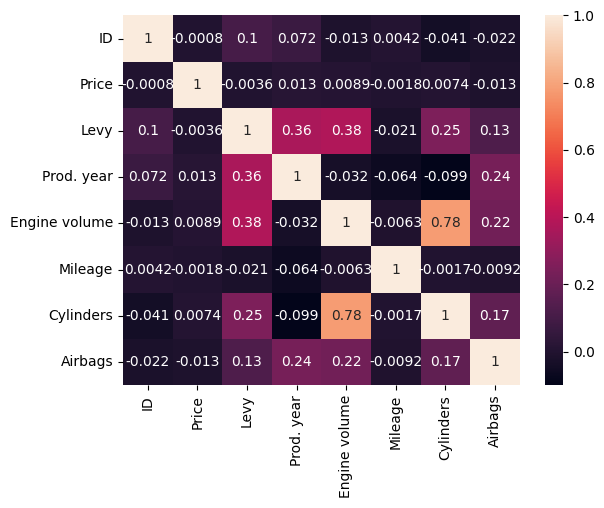

In [18]:
sns.heatmap(data.corr(numeric_only=True), annot=True)

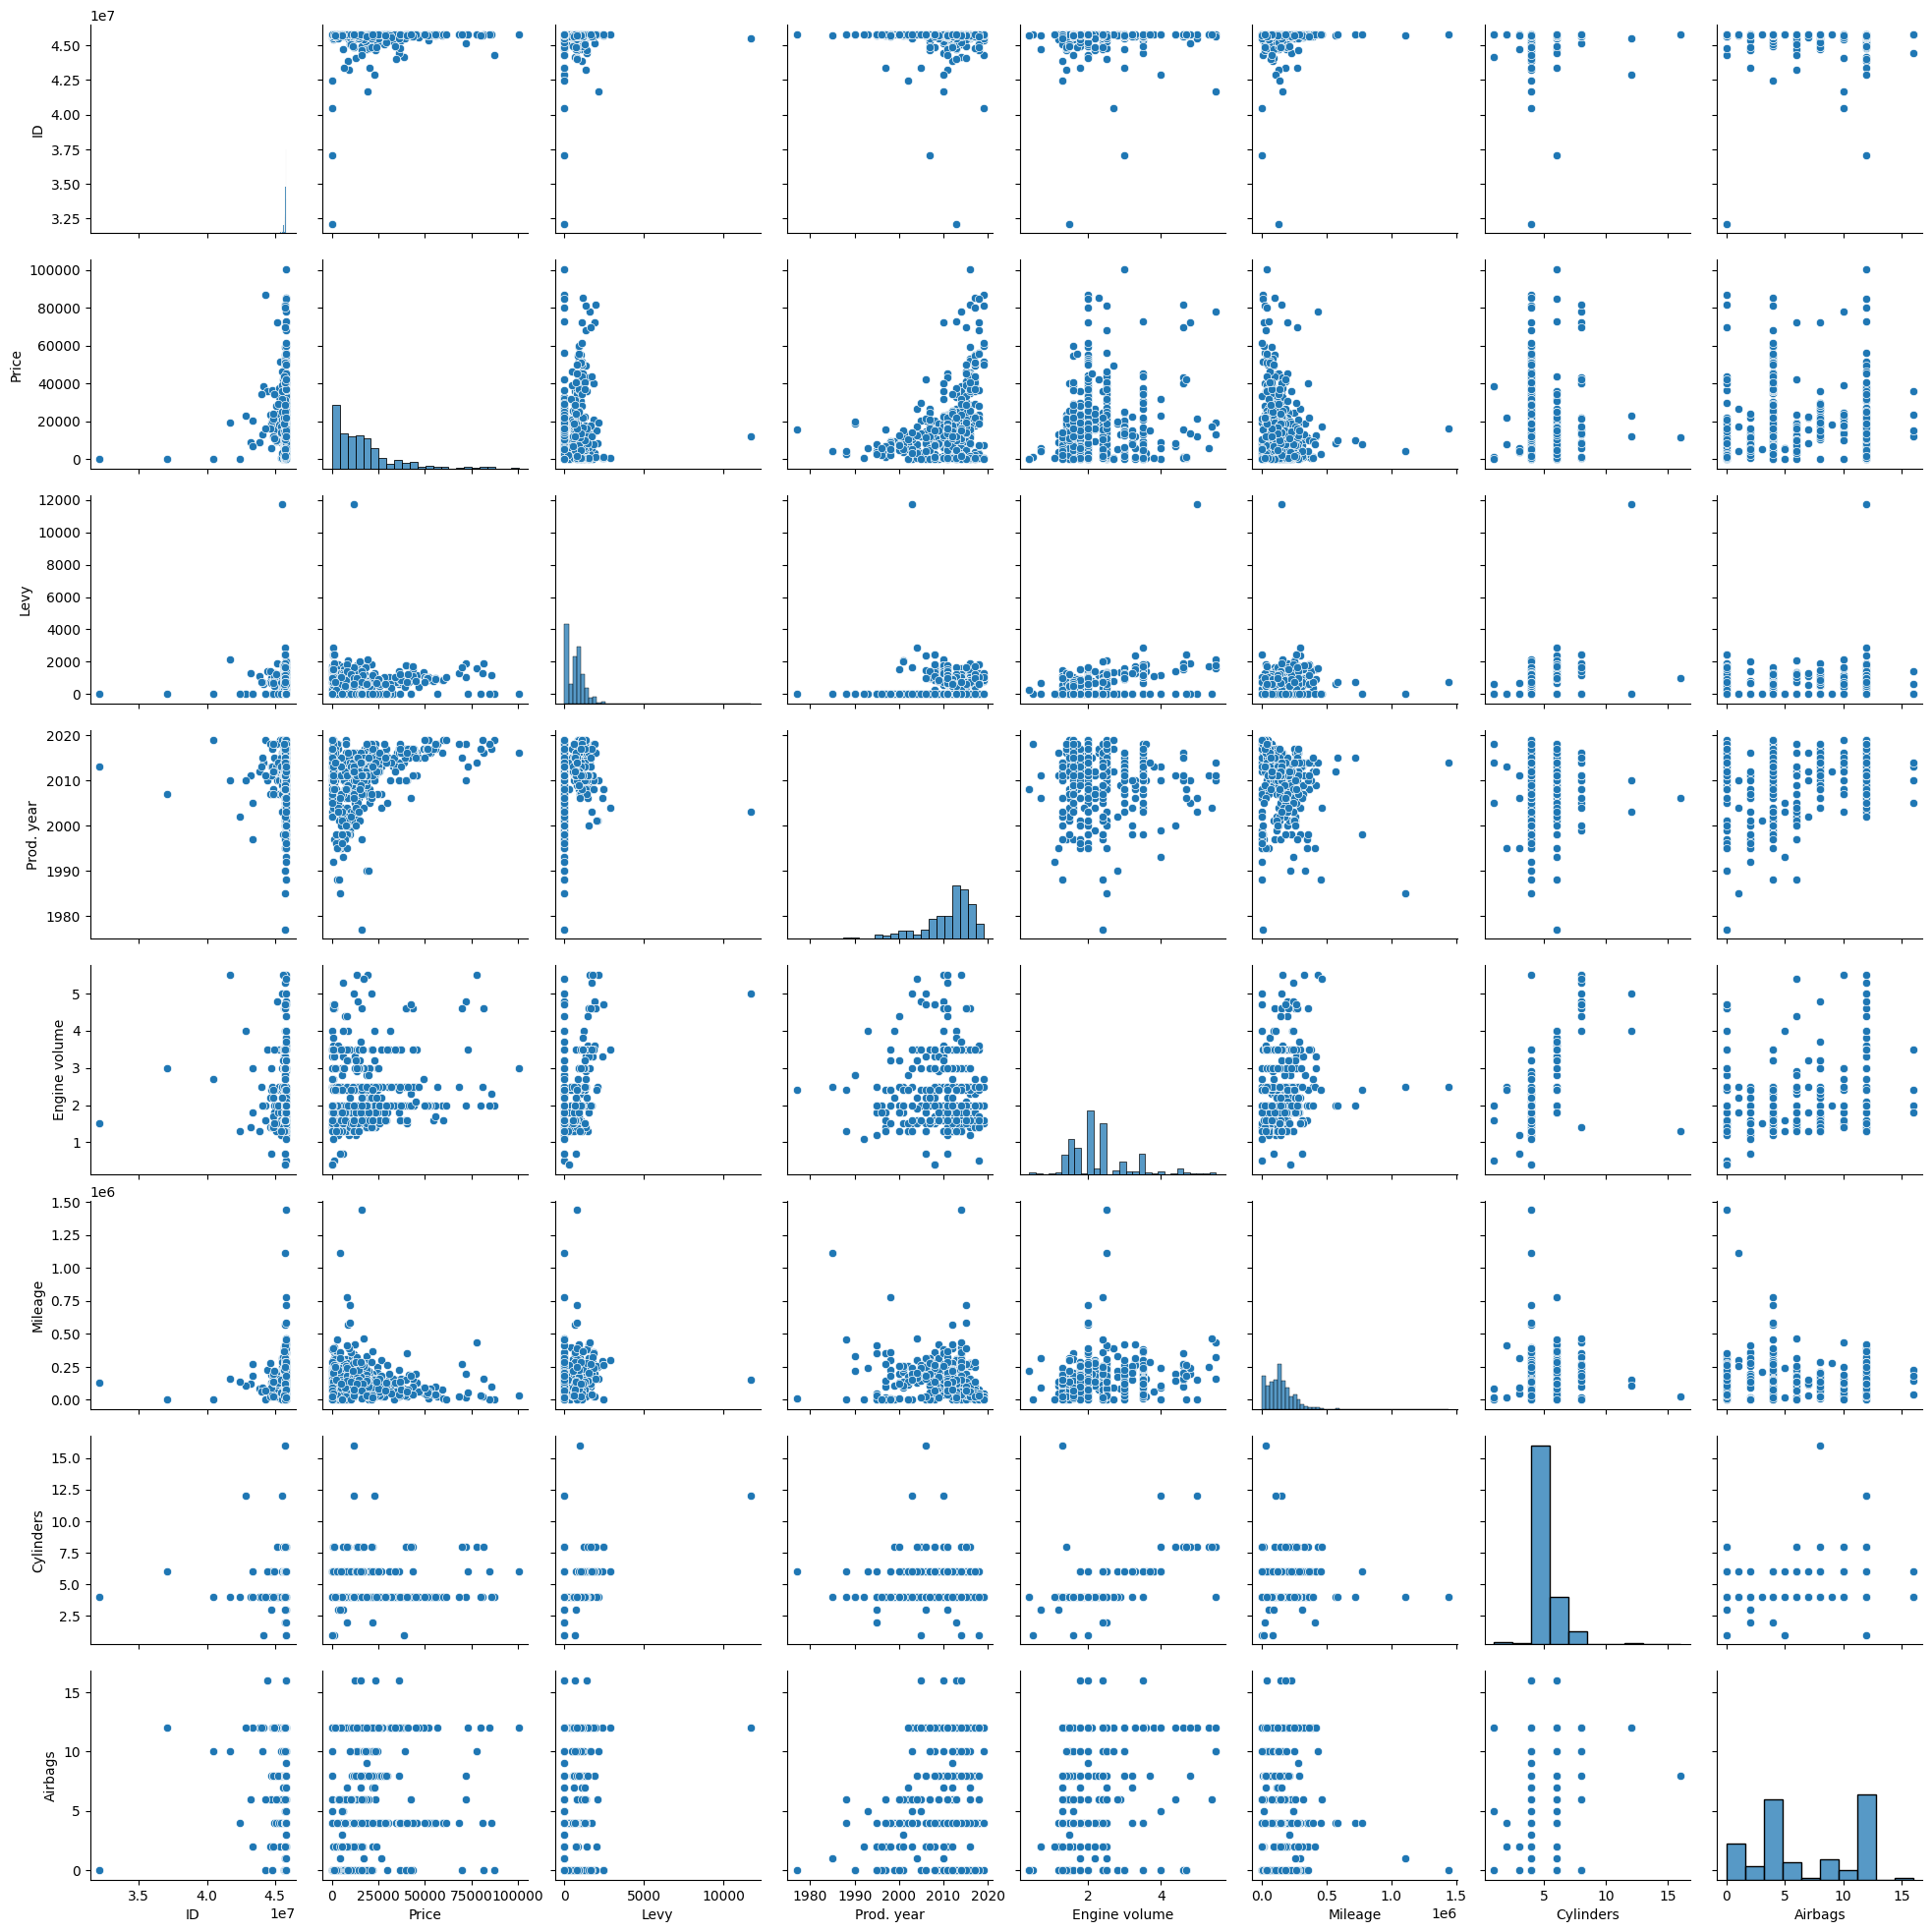

In [19]:
sns.pairplot(data[:500])

<Axes: ylabel='Price'>

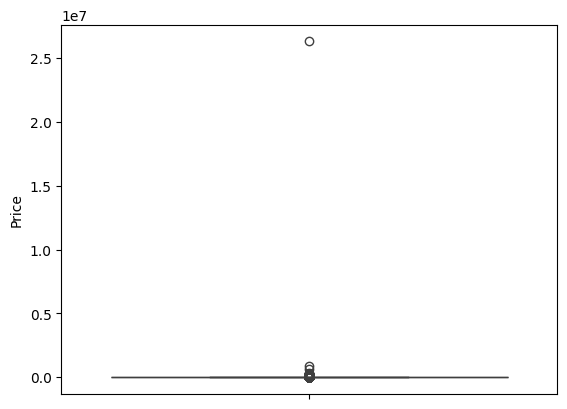

In [20]:
sns.boxplot(data['Price'])

In [ ]:
data[data['Price']>5e5]

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
1225,45795524,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3,0.0,8.0,Tiptronic,4x4,Left wheel,Black,12
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531.0,8.0,Tiptronic,4x4,Left wheel,Black,0
16983,45812886,26307500,0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999.0,4.0,Manual,Front,Left wheel,Blue,0


<Axes: ylabel='Levy'>

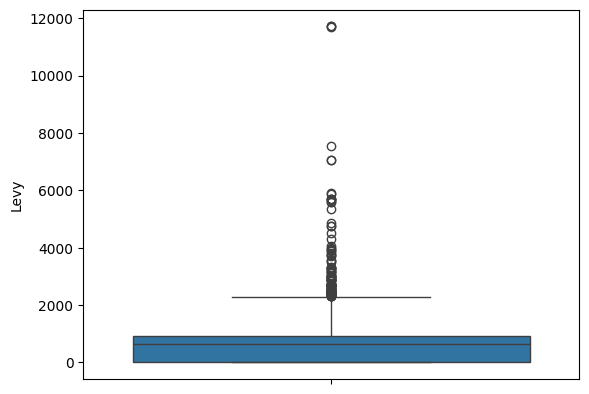

In [22]:
sns.boxplot(data['Levy'])

<Axes: ylabel='Mileage'>

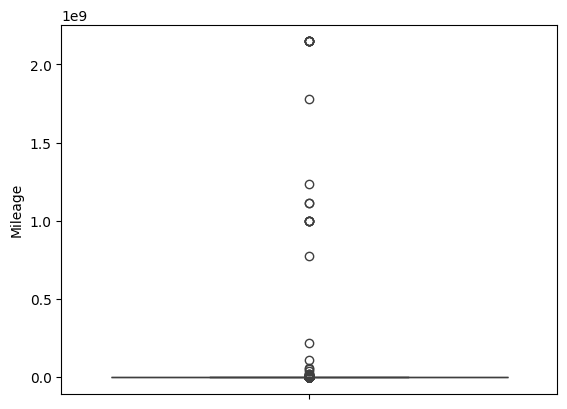

In [23]:
sns.boxplot(data['Mileage'])

In [24]:
def clean_outliers(df,col):
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1

  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  df_no_outliers=df[(df[col]>=lower_bound) & ([col]<=upper_bound)]
  return df_no_outliers

In [39]:
data.shape

(16476, 17)

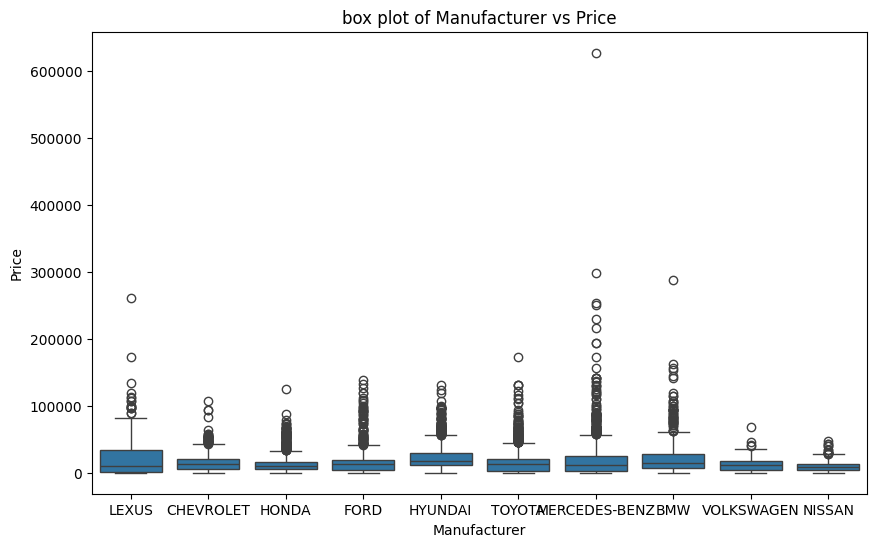

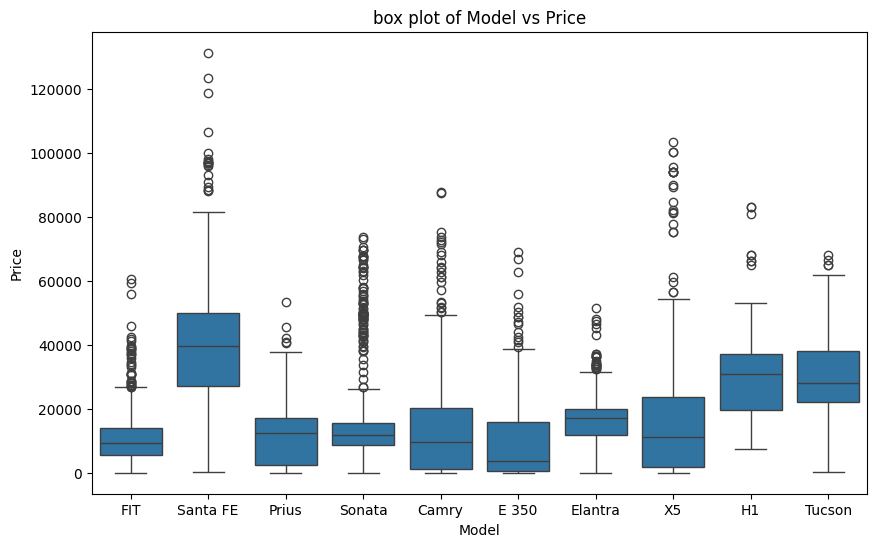

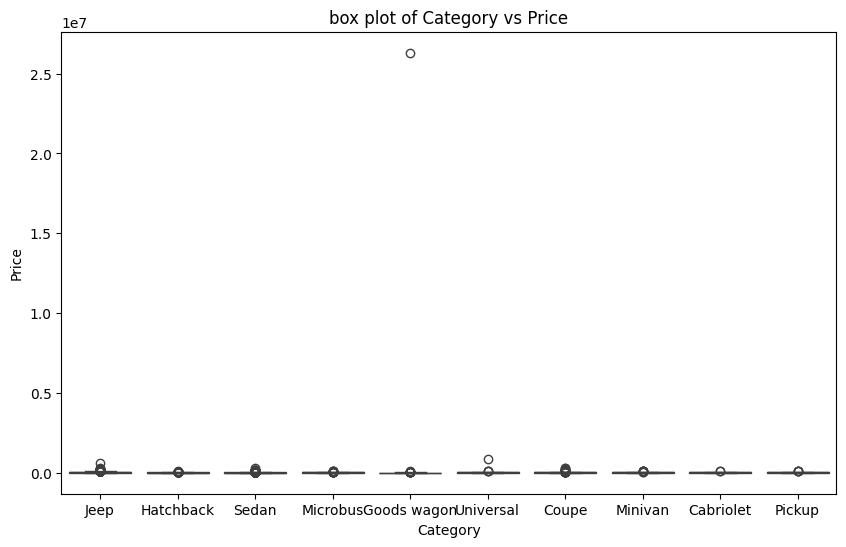

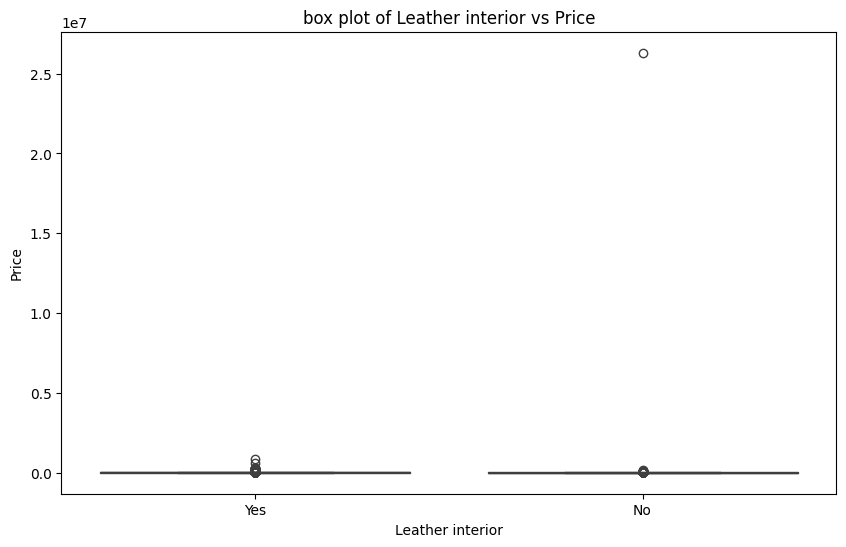

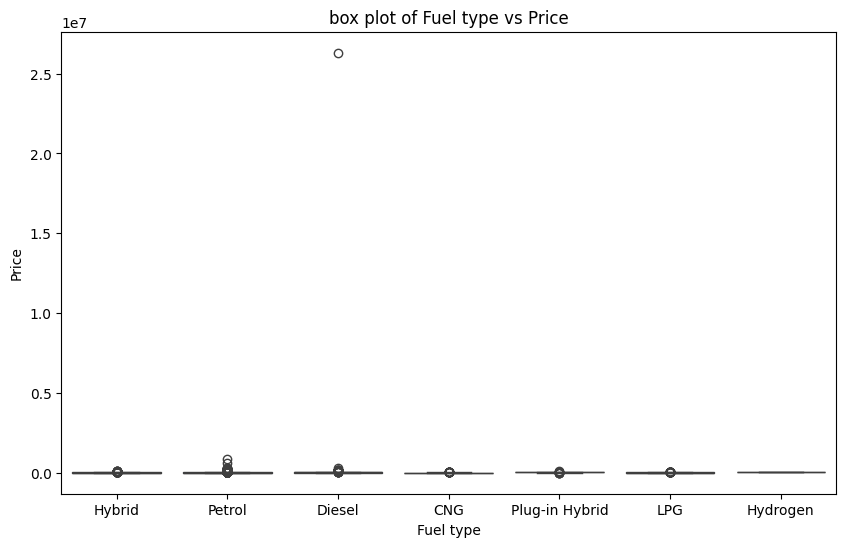

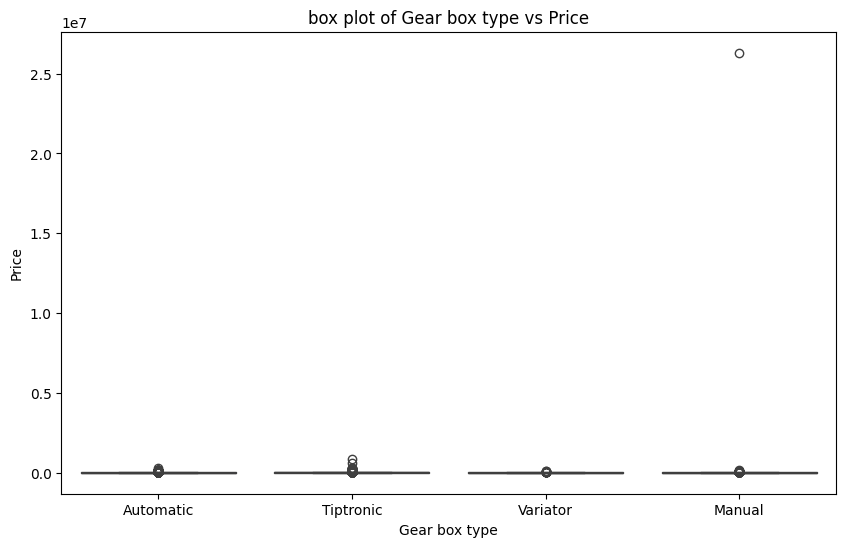

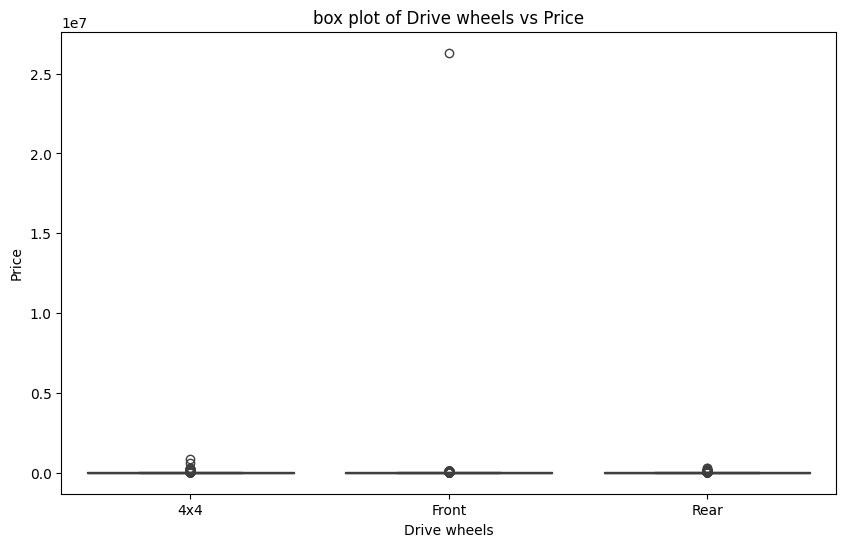

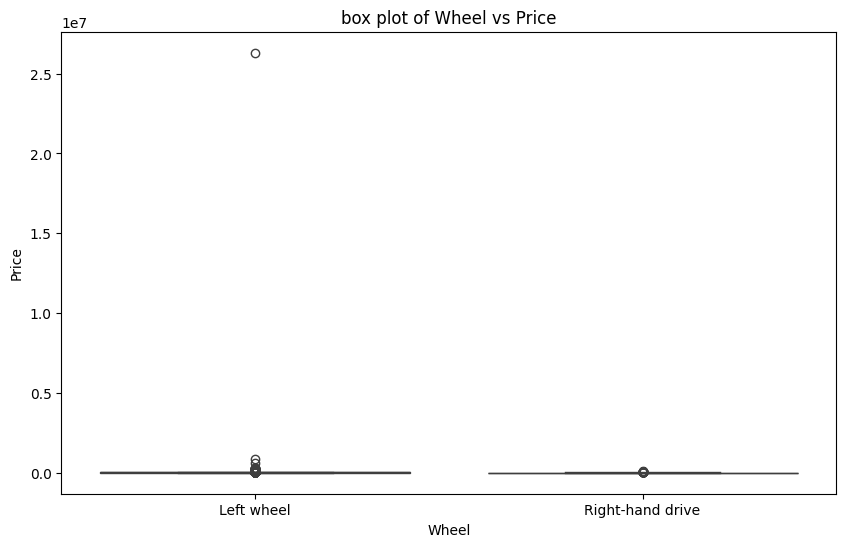

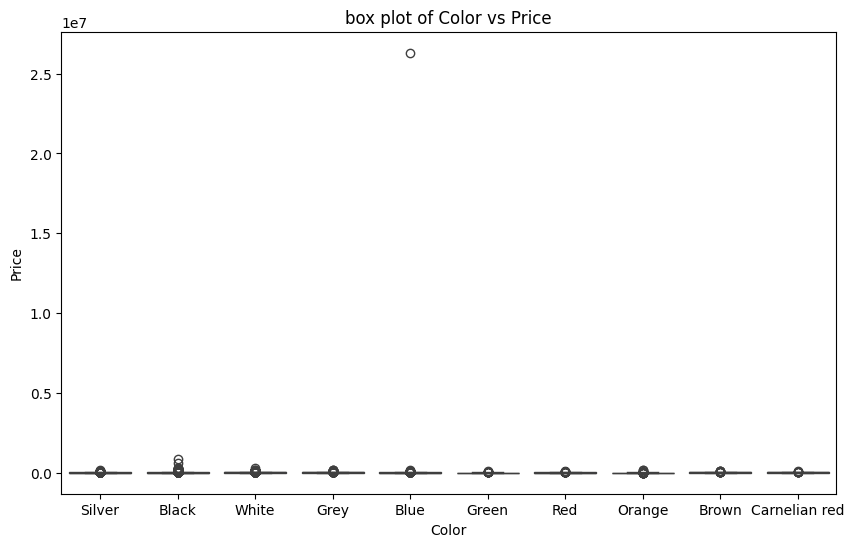

In [27]:
for col in data.select_dtypes('object'):
  top_categories=data[col].value_counts().index[:10]
  filtered_df=data[data[col].isin(top_categories)]

  plt.figure(figsize=(10,6))
  sns.boxplot(x=filtered_df[col],y=filtered_df['Price'])
  plt.title(f'box plot of {col} vs Price')
  plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

# one_hot_columns=['Leather interior','Gear box type','Drive wheels','Wheel']
# data=pd.get_dummies(data,columns=one_hot_columns) # This line was removed as columns are already processed

label_encode_columns=['Manufacturer','Model','Category','Fuel type','Color']
label_encoder=LabelEncoder()
for col_name in label_encode_columns:
  data[col_name]=label_encoder.fit_transform(data[col_name])

In [34]:
X=data.drop('Price',axis=1)
Y=data['Price']

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_temp,Y_train,Y_temp=train_test_split(X,Y,test_size=0.3,random_state=42)
X_val,X_test,Y_val,Y_test=train_test_split(X_temp,Y_temp,test_size=0.5,random_state=42)

print(f"Train Set :{len(X_train)} samples")
print(f"Validation Set {len(X_val)} Samples")
print(f"Test Set {len(X_test)} Samples")

Train Set :13246 samples
Validation Set 2839 Samples
Test Set 2839 Samples


In [41]:
target_encoding_columns=['Fuel type','Model','Airbags','Cylinders','Manufacturer']
train=pd.concat([X_train,Y_train], axis=1)
for col in target_encoding_columns:
  mean_encoded=train.groupby(col)['Price'].mean()
  global_mean=train['Price'].mean()
  X_val[col]=X_val[col].map(mean_encoded).fillna(global_mean)
  X_test[col]=X_test[col].map(mean_encoded).fillna(global_mean)

In [45]:
from sklearn.preprocessing import StandardScaler
numerical_columns = ['Levy','Engine volume','Mileage','Prod. year','Fuel type','Model','Airbags','Cylinders','Manufacturer']
scaler=StandardScaler()
X_train [numerical_columns]=scaler.fit_transform(X_train[numerical_columns])
X_val[numerical_columns]=scaler.transform(X_val[numerical_columns])
X_test[numerical_columns]=scaler.transform(X_test[numerical_columns])

In [47]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,Y_train)

LinearRegression()

In [49]:
from sklearn.metrics import mean_squared_error ,r2_score
import numpy as np
Y_val_pred=lr.predict(X_val)
mse=mean_squared_error(Y_val,Y_val_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_val,Y_val_pred)

print(f"Root Mean Squared Error : {rmse}")
print(f"R^2 Score : {r2}")

Root Mean Squared Error : 34445491.26036225
R^2 Score : -4340191.477037095


In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf=RandomForestRegressor()
rf.fit(X_train,Y_train)

Y_val_pred=rf.predict(X_val)
mse=mean_squared_error(Y_val,Y_val_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_val,Y_val_pred)

print(f"Root Mean Squared Error : {rmse}")
print(f"R^2 Score : {r2}")

ImportError: cannot import name 'RandomForestRegression' from 'sklearn.ensemble' (/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/__init__.py)

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf=RandomForestRegressor()
rf.fit(X_train,Y_train)

Y_val_pred=rf.predict(X_val)
mse=mean_squared_error(Y_val,Y_val_pred)
rmse=np.sqrt(mse)
r2=r2_score(Y_val,Y_val_pred)

print(f"Root Mean Squared Error : {rmse}")
print(f"R^2 Score : {r2}")

Root Mean Squared Error : 32695.531895594926
R^2 Score : -2.910398680150295
